# 2단계 — SARATR-X 분류기 학습 (SOC-50)

## 이 노트북의 역할
분류기 5종 비교의 **본명** — SAR 파운데이션 모델 SARATR-X(IEEE TIP 2025)를 SOC-50에 파인튜닝.
논문(ATRBench) 기준 SOC-50 1위 모델(85.2%)이며, 우리 레시피로 ResNet18(80.49%)을 넘는지가 관전 포인트.

## SARATR-X란
- **HiViT-base 백본** + 18만 장의 무라벨 SAR 표적 이미지로 **자기지도(MAE 방식) 사전학습**한 모델
- ImageNet(일반 사진) 사전학습과 달리 **SAR 도메인 자체를 사전학습** → SAR 표적인식에 특화된 표현 학습
- 우리는 이 사전학습 가중치에서 시작해 분류층만 붙여 SOC-50으로 파인튜닝 (전이학습)

## ResNet 노트북과의 차이점 (불가피한 변경)
| 항목 | ResNet18 | SARATR-X | 이유 |
|---|---|---|---|
| 입력 크기 | 128 | **224** | HiViT가 224 기준 사전학습 (패치 구조 고정) |
| batch | 256 | **64** (T4) / 256 (A100) | ViT-base는 메모리 사용량 큼 |
| AMP(혼합 정밀도) | 미사용 | **사용** | 학습 속도 2배 (큰 모델이라 필수적) |
| 증강/LR/에폭/손실 | — | **동일 유지** | 공정 비교의 핵심 (증강 레시피 + label smoothing 0.1 + 30ep + AdamW 1e-4) |

보고서에는 입력 크기/배치 차이를 명시할 것 — 모델 구조상 불가피한 차이.

## 사전 준비
1. HF에서 SARATR-X 약관 동의: https://huggingface.co/waterdisappear/SARATR-X (gated 모델 — 동의 없이는 다운로드 불가)
2. 드라이브 `MyDrive/ATRNet-STAR/soc50.tar`
3. 런타임 → **A100 권장** (T4도 가능하나 2~3시간)

## ⚠ 이 노트북의 특성
공식 repo 코드를 가져와 쓰기 때문에 ResNet 노트북보다 탐색 단계가 많다.
셀 3~5는 "확인 → 다음 셀에 반영" 구조이니 출력을 보면서 진행할 것.

## 1. 환경 준비

- GPU 확인 + 드라이브 마운트 + HF 로그인 (gated 모델 다운로드용)
- `timm`: HiViT 코드가 의존하는 라이브러리 (DropPath, trunc_normal_ 등 레이어 유틸)
- GitHub repo clone: HiViT 백본 정의 코드(`models_hivit.py`)를 가져오기 위함

In [ ]:
import torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음 — 런타임 유형 변경!")

from google.colab import drive
drive.mount('/content/drive')

# HiViT 코드 의존성. 최신 timm으로 먼저 시도 — 실패 시 아래 주석 해제해 구버전 설치
!pip -q install timm
# !pip -q install timm==0.5.4   # ← import 에러 나면 이걸로 교체 후 런타임 재시작

# SARATR-X 공식 repo (HiViT 모델 정의 코드 사용 목적)
!git clone -q https://github.com/waterdisappear/SARATR-X.git /content/SARATR-X
!ls /content/SARATR-X/pre-training/models/   # models_hivit.py 가 있는지 확인

GPU: NVIDIA A100-SXM4-40GB
Mounted at /content/drive
__init__.py	       models_hivit_mae.py  models_vit_mae.py  __pycache__
masked_autoencoder.py  models_hivit.py	    models_vit.py


## 2. 사전학습 가중치 다운로드 (HF, gated)

- `weight/` 폴더에 사전학습 체크포인트가 있음 (186K_all / 186K_notest 두 버전)
- **186K_notest 사용 권장**: 사전학습 데이터에서 test 관련 샘플을 뺀 버전 —
  MSTAR가 사전학습에 포함되므로 우리 SOC-50 test(MSTAR 포함)와의 정보 누출을 줄이려면 notest가 안전
- 파일명을 모르므로 먼저 목록을 출력해 확인 후 다운로드

In [ ]:
from huggingface_hub import login, list_repo_files, hf_hub_download
login()   # hf_... 토큰 입력 (SARATR-X 약관 동의된 계정이어야 함)

# weight 폴더의 체크포인트 파일 목록 확인
files = list_repo_files("waterdisappear/SARATR-X")
weight_files = [f for f in files if f.startswith("weight/")]
for f in weight_files:
    print(f)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


weight/186K_all/checkpoint-200.pth
weight/186K_all/checkpoint-400.pth
weight/186K_all/checkpoint-600.pth
weight/186K_all/checkpoint-800.pth
weight/186K_all/events.out.tfevents.1706663091.vgc-SYS-4029GP-TRT.4906.0
weight/186K_all/log.txt
weight/186K_notest/checkpoint-600.pth
weight/186K_notest/events.out.tfevents.1711868582.vgc-SYS-4029GP-TRT.24781.0
weight/186K_notest/log.txt


In [ ]:
# ▼ 위 출력에서 186K_notest 폴더의 .pth 파일명을 확인해 지정
CKPT_FILE = [f for f in weight_files if "notest" in f and f.endswith(".pth")][0]
print("다운로드:", CKPT_FILE)

ckpt_path = hf_hub_download("waterdisappear/SARATR-X", CKPT_FILE, local_dir="/content/weights")
print("저장 위치:", ckpt_path)

다운로드: weight/186K_notest/checkpoint-600.pth


weight/186K_notest/checkpoint-600.pth:   0%|          | 0.00/1.04G [00:00<?, ?B/s]

저장 위치: /content/weights/weight/186K_notest/checkpoint-600.pth


## 3. 체크포인트 내용 확인 (탐색 셀)

MAE 방식 사전학습 체크포인트는 보통 이런 구조:
- `{"model": state_dict, ...}` 형태로 감싸져 있음
- 인코더(백본) 가중치 + 디코더(복원용) 가중치가 섞여 있음 — **분류에는 인코더만 필요**
- 키 이름(`patch_embed...`, `blocks...`)이 모델 정의와 일치해야 로드됨

아래 출력으로 구조를 확인하고 다음 셀의 로드 방식을 검증한다.

In [ ]:
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

print("최상위 키:", list(ckpt.keys()) if isinstance(ckpt, dict) else type(ckpt))

# state_dict 꺼내기 ("model" 키로 감싸진 경우가 일반적)
sd = ckpt.get("model", ckpt) if isinstance(ckpt, dict) else ckpt

keys = list(sd.keys())
print(f"\n파라미터 텐서 수: {len(keys)}")
print("앞 10개 키:")
for k in keys[:10]:
    print("  ", k, tuple(sd[k].shape))
print("뒤 5개 키:")
for k in keys[-5:]:
    print("  ", k, tuple(sd[k].shape))
# decoder_* 키가 보이면 MAE 디코더 — 로드 시 무시됨(strict=False)

최상위 키: ['model', 'optimizer', 'epoch', 'scaler', 'args']

파라미터 텐서 수: 393
앞 10개 키:
   absolute_pos_embed (1, 196, 512)
   mask_token (1, 1, 512)
   decoder_pos_embed (1, 196, 512)
   patch_embed.proj.weight (128, 3, 4, 4)
   patch_embed.proj.bias (128,)
   patch_embed.norm.weight (128,)
   patch_embed.norm.bias (128,)
   blocks.0.norm2.weight (128,)
   blocks.0.norm2.bias (128,)
   blocks.0.mlp.fc1.weight (384, 128)
뒤 5개 키:
   decoder_blocks.5.mlp.fc2.bias (512,)
   decoder_norm.weight (512,)
   decoder_norm.bias (512,)
   decoder_pred.weight (768, 512)
   decoder_pred.bias (768,)


## 4. HiViT 백본 생성 + 가중치 로드

- repo의 `models_hivit.py`에서 HiViT-base를 생성 (사전학습과 동일 구조여야 키가 맞음)
- `strict=False` 로드: MAE 디코더 키, mask token 등 분류에 불필요한 키는 무시
- **missing keys에 백본 핵심 키(blocks, patch_embed)가 나오면 안 됨** — 출력 확인 필수
- 분류 헤드: HiViT 출력 특징을 평균 풀링 → Linear(50)

⚠ repo 코드 버전에 따라 함수명이 다를 수 있음 — 에러 시 `dir(models_hivit)` 출력에서 hivit_base 계열 함수명 확인

In [ ]:
import sys
import torch.nn as nn

sys.path.insert(0, "/content/SARATR-X/pre-training")   # repo 모델 코드 import 경로 추가
from models import models_hivit                          # HiViT 정의 모듈

print("사용 가능한 모델 함수:", [n for n in dir(models_hivit) if "hivit" in n.lower()])

# ▼ 위 출력에서 base 모델 함수명 확인 후 필요시 수정
backbone = models_hivit.hivit_base()          # HiViT-base 생성 (224 입력 기준)

# 사전학습 가중치 로드 — 디코더 등 불일치 키는 무시
msg = backbone.load_state_dict(sd, strict=False)
print("\nmissing keys (모델에 있는데 ckpt에 없음):", len(msg.missing_keys))
print("  예시:", msg.missing_keys[:5])
print("unexpected keys (ckpt에 있는데 모델에 없음):", len(msg.unexpected_keys))
print("  예시:", msg.unexpected_keys[:5])
# missing에 blocks/patch_embed가 대량으로 나오면 구조 불일치 — 모델 함수명 재확인 필요

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


사용 가능한 모델 함수: ['HiViT', 'hivit_base']

missing keys (모델에 있는데 ckpt에 없음): 25
  예시: ['relative_position_index', 'blocks.10.attn.relative_position_bias_table', 'blocks.11.attn.relative_position_bias_table', 'blocks.12.attn.relative_position_bias_table', 'blocks.13.attn.relative_position_bias_table']
unexpected keys (ckpt에 있는데 모델에 없음): 94
  예시: ['mask_token', 'decoder_pos_embed', 'norm.weight', 'norm.bias', 'hogs2.weight_x1']


In [ ]:
# 분류 모델 래퍼: HiViT 백본 → 특징 평균 풀링 → 50클래스 Linear
class SARATRXClassifier(nn.Module):
    def __init__(self, backbone, num_classes, feat_dim=512):   # HiViT-base 최종 차원 = 512
        super().__init__()
        self.backbone = backbone
        self.norm = nn.LayerNorm(feat_dim)        # ViT 관례: 특징 정규화 후 헤드
        self.head = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        feats = self.backbone.forward_features(x)  # (B, N_patches, C) 토큰 특징
        if feats.dim() == 3:
            feats = feats.mean(dim=1)              # 패치 토큰 평균 풀링 → (B, C)
        return self.head(self.norm(feats))

# 특징 차원 자동 확인 (더미 입력 1장 통과)
with torch.no_grad():
    dummy = backbone.forward_features(torch.zeros(1, 3, 224, 224))
feat_dim = dummy.shape[-1]
print(f"백본 출력 형태: {tuple(dummy.shape)} → feat_dim={feat_dim}")

NUM_CLASSES = 50
device = torch.device("cuda")
model = SARATRXClassifier(backbone, NUM_CLASSES, feat_dim).to(device)
print(f"전체 파라미터: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

백본 출력 형태: (1, 196, 512) → feat_dim=512
전체 파라미터: 66.4M


## 5. 데이터 준비 + 데이터로더

ResNet 노트북과 동일한 증강 레시피, 단 **Resize 224** (HiViT 입력 규격).
- 공정 비교 항목 유지: RandomHorizontalFlip + RandomAffine(10°, 0.1) + RandomErasing(0.3),
  label smoothing 0.1, 30에폭, AdamW lr 1e-4 + cosine
- 차이 항목(입력 224, batch, AMP)은 모델 구조상 불가피 — 보고서에 명시

In [ ]:
import os
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# ----- SOC-50 해제 (이미 있으면 건너뜀) -----
SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
DATA_DIR = "/content/SOC_50classes"
if not os.path.exists(DATA_DIR):
    !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
    !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# ----- 증강 레시피는 ResNet과 동일, 입력만 224 -----
train_transform = T.Compose([
    T.Resize((224, 224)),                              # HiViT 입력 규격 (128→224 업스케일)
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(),
    T.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.RandomErasing(p=0.3),
])
test_transform = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
])

train_ds = ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds  = ImageFolder(TEST_DIR,  transform=test_transform)

BATCH = 128 if "A100" in torch.cuda.get_device_name(0) else 32   # GPU별 배치 자동
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

assert len(train_ds.classes) == NUM_CLASSES
print(f"train {len(train_ds)} / test {len(test_ds)} / batch {BATCH}")

train 18071 / test 17603 / batch 128


## 6. 학습 루프 (AMP + 체크포인트)

ResNet 노트북과 같은 구조에 **AMP(자동 혼합 정밀도)** 추가:
- `autocast()`: 순전파를 FP16으로 계산 → 메모리 절반, 속도 ~2배 (ViT-base에 필수적)
- `GradScaler`: FP16에서 기울기가 너무 작아져 0이 되는 것(underflow)을 방지하는 스케일링
- 에폭마다 드라이브 체크포인트 → 세션 끊겨도 재실행으로 이어 학습

**예상 시간**: A100 ~40분 / T4 2~3시간 (30에폭)

In [ ]:
import time

MODEL_NAME = "saratrx_soc50"
EPOCHS = 30
LR = 1e-4

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)                            # ResNet과 동일
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()                                             # AMP용

os.makedirs(f"{SAVE_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/results", exist_ok=True)
CKPT_PATH = f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_ckpt.pth"

# ----- 체크포인트 이어 학습 -----
start_epoch, history = 0, []
if os.path.exists(CKPT_PATH):
    c = torch.load(CKPT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(c["model"]); optimizer.load_state_dict(c["optimizer"])
    scheduler.load_state_dict(c["scheduler"]); scaler.load_state_dict(c["scaler"])
    start_epoch, history = c["epoch"] + 1, c["history"]
    print(f"체크포인트 발견 → 에폭 {start_epoch + 1}부터 재개")

t0 = time.time()
for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():        # FP16 순전파 (메모리/속도 이득)
            out = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()           # 스케일된 손실로 역전파 (underflow 방지)
        scaler.step(optimizer)                  # 가중치 갱신
        scaler.update()                         # 스케일 팩터 자동 조정

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        n += x.size(0)

    scheduler.step()
    history.append({"epoch": epoch, "train_loss": total_loss/n, "train_acc": correct/n})
    print(f"Epoch {epoch+1}/{EPOCHS} | loss {total_loss/n:.4f} | acc {correct/n:.4f} "
          f"| 누적 {(time.time()-t0)/60:.1f}분")

    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                "epoch": epoch, "history": history}, CKPT_PATH)

print("학습 완료")

/tmp/ipykernel_4397/2835022115.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()                                             # AMP용
/tmp/ipykernel_4397/2835022115.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():        # FP16 순전파 (메모리/속도 이득)


Epoch 1/30 | loss 3.2074 | acc 0.1776 | 누적 0.7분
Epoch 2/30 | loss 2.3410 | acc 0.4306 | 누적 1.3분
Epoch 3/30 | loss 1.8087 | acc 0.6113 | 누적 2.0분
Epoch 4/30 | loss 1.4900 | acc 0.7235 | 누적 2.7분
Epoch 5/30 | loss 1.2755 | acc 0.8083 | 누적 3.4분
Epoch 6/30 | loss 1.1536 | acc 0.8533 | 누적 4.0분
Epoch 7/30 | loss 1.0619 | acc 0.8892 | 누적 4.7분
Epoch 8/30 | loss 1.0029 | acc 0.9113 | 누적 5.4분
Epoch 9/30 | loss 0.9557 | acc 0.9276 | 누적 6.5분
Epoch 10/30 | loss 0.9163 | acc 0.9428 | 누적 7.2분
Epoch 11/30 | loss 0.8849 | acc 0.9515 | 누적 8.2분
Epoch 12/30 | loss 0.8794 | acc 0.9531 | 누적 9.4분
Epoch 13/30 | loss 0.8649 | acc 0.9558 | 누적 10.0분
Epoch 14/30 | loss 0.8482 | acc 0.9612 | 누적 10.7분
Epoch 15/30 | loss 0.8394 | acc 0.9644 | 누적 11.8분
Epoch 16/30 | loss 0.8289 | acc 0.9669 | 누적 12.5분
Epoch 17/30 | loss 0.8239 | acc 0.9673 | 누적 13.2분
Epoch 18/30 | loss 0.8094 | acc 0.9726 | 누적 13.8분
Epoch 19/30 | loss 0.8063 | acc 0.9726 | 누적 14.9분
Epoch 20/30 | loss 0.8027 | acc 0.9733 | 누적 16.0분
Epoch 21/30 | loss 0.

## 7. 평가 + 결과 저장

ResNet 노트북과 동일한 형식으로 json 저장 → 비교 노트북에서 그대로 사용.
비교 기준: 논문 SARATR-X SOC-50 = **85.2%**, 우리 ResNet18 = 80.49%

In [ ]:
import json
import numpy as np

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        with torch.cuda.amp.autocast():
            out = model(x.to(device, non_blocking=True))
        y_pred.extend(out.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

y_true, y_pred = np.array(y_true), np.array(y_pred)
overall_acc = float((y_true == y_pred).mean())
per_class_acc = {cls: float((y_pred[y_true == i] == i).mean())
                 for i, cls in enumerate(test_ds.classes) if (y_true == i).sum() > 0}

print(f"Overall Accuracy: {overall_acc*100:.2f}%")
print(f"(비교: 논문 SARATR-X 85.2% / 우리 ResNet18 80.49%)")

result = {"model": MODEL_NAME, "setting": "SOC-50", "epochs": EPOCHS, "lr": LR,
          "input_size": 224, "batch": BATCH,        # ResNet과 다른 항목 기록
          "overall_acc": overall_acc, "per_class_acc": per_class_acc,
          "classes": test_ds.classes, "y_true": y_true.tolist(), "y_pred": y_pred.tolist(),
          "history": history}
with open(f"{SAVE_DIR}/results/{MODEL_NAME}.json", "w") as f:
    json.dump(result, f)

torch.save(model.state_dict(), f"{SAVE_DIR}/checkpoints/{MODEL_NAME}_final.pth")
print("저장 완료:", f"results/{MODEL_NAME}.json + checkpoints/{MODEL_NAME}_final.pth")

/tmp/ipykernel_4397/923114596.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Overall Accuracy: 89.30%
(비교: 논문 SARATR-X 85.2% / 우리 ResNet18 80.49%)
저장 완료: results/saratrx_soc50.json + checkpoints/saratrx_soc50_final.pth


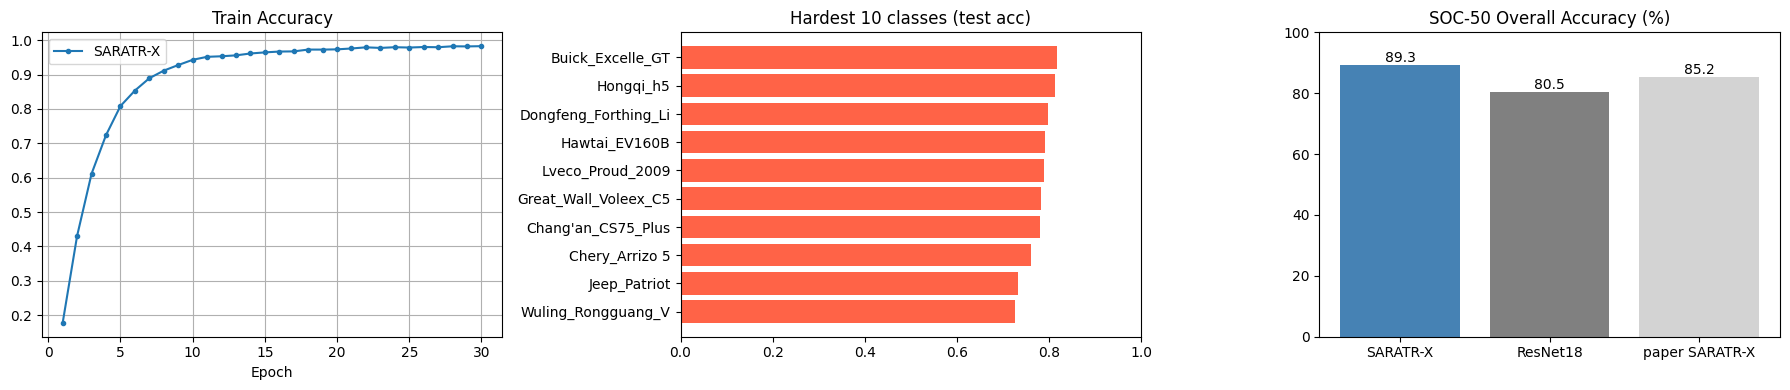

In [ ]:
# 8. 결과 시각화 — 학습 곡선 + 어려운 클래스 + ResNet18 비교
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# (1) 학습 곡선: train accuracy 추이
axes[0].plot([h["epoch"]+1 for h in history], [h["train_acc"] for h in history],
             marker="o", ms=3, label="SARATR-X")
axes[0].set_title("Train Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].grid(True); axes[0].legend()

# (2) 가장 어려운 클래스 Top 10 (test 기준)
sorted_cls = sorted(per_class_acc.items(), key=lambda x: x[1])
axes[1].barh([c[:20] for c, _ in sorted_cls[:10]], [a for _, a in sorted_cls[:10]], color="tomato")
axes[1].set_title("Hardest 10 classes (test acc)"); axes[1].set_xlim(0, 1)

# (3) ResNet18 결과와 모델 비교 (드라이브의 json 재사용)
import json
comp = {"SARATR-X": overall_acc}
try:
    with open(f"{SAVE_DIR}/results/resnet18_soc50.json") as f:
        comp["ResNet18"] = json.load(f)["overall_acc"]
except FileNotFoundError:
    pass
comp["paper SARATR-X"] = 0.852   # 논문 기준치

names, accs = list(comp.keys()), [v*100 for v in comp.values()]
bars = axes[2].bar(names, accs, color=["steelblue", "gray", "lightgray"][:len(names)])
axes[2].set_title("SOC-50 Overall Accuracy (%)"); axes[2].set_ylim(0, 100)
for b, a in zip(bars, accs):
    axes[2].text(b.get_x() + b.get_width()/2, a + 1, f"{a:.1f}", ha="center")

plt.tight_layout(); plt.show()

## 8. pipeline_inference에서 이 모델 쓰는 법

셀 3의 분류기 블록을 아래로 교체 (repo 경로 + 래퍼 클래스 필요):
```python
sys.path.insert(0, "/content/SARATR-X/pre-training")
from models import models_hivit
backbone = models_hivit.hivit_base()
classifier = SARATRXClassifier(backbone, NUM_CLASSES, feat_dim=512)   # 래퍼 클래스 정의 복사 필요
classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/saratrx_soc50_final.pth", map_location=device))
classifier = classifier.to(device).eval()
# ⚠ cls_transform의 Resize를 (224, 224)로 변경해야 함 (크롭 128 창 → 224 리사이즈)
```

## 트러블슈팅

| 증상 | 원인 | 대응 |
|---|---|---|
| `from models import models_hivit` 실패 | timm 버전 비호환 | 셀 1에서 `timm==0.5.4` 설치 후 런타임 재시작 |
| missing keys에 blocks 대량 | 모델 함수/구조 불일치 | 셀 4의 `dir()` 출력에서 올바른 함수명 확인 |
| `forward_features` 없음 에러 | repo 버전 차이 | `backbone(x)` 또는 `backbone.forward(x)`로 교체 후 출력 shape 확인 |
| OOM | 배치 과대 | BATCH를 절반으로 (64→32) |